<a href="https://colab.research.google.com/github/bimamj/PCVK_2026/blob/main/Modul3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Linear Brightness Transformation

Mengubah tingkat kecerahan citra
----------------------------------
Masukkan nilai kecerahan: 60


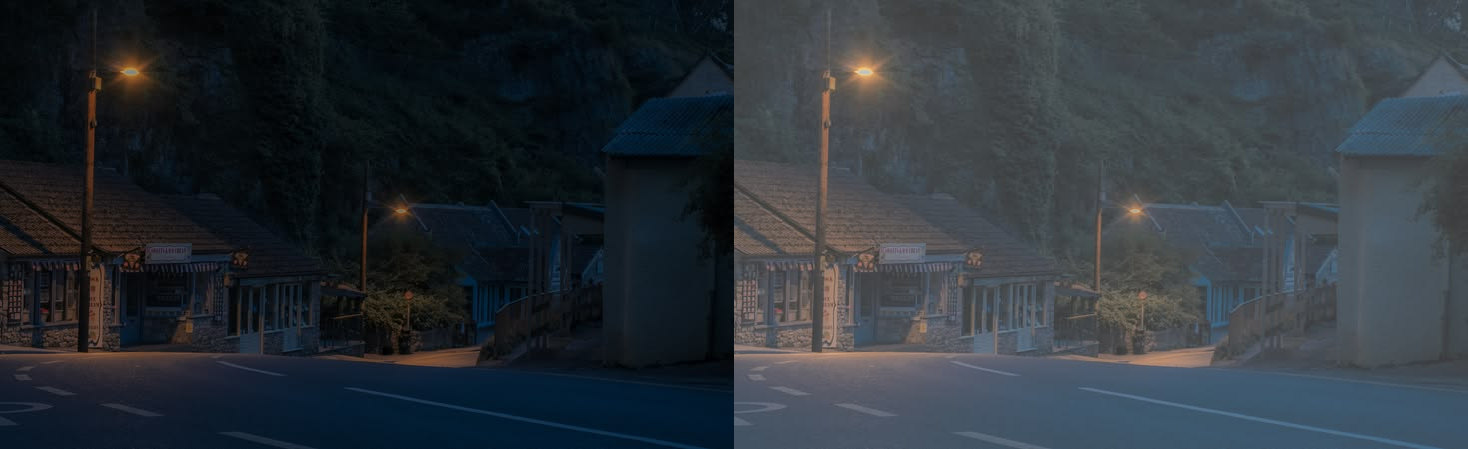

In [ ]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow


print('Mengubah tingkat kecerahan citra')
print('----------------------------------')
try:
  brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
  print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK/night town.jpg')

brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat([original, brightness_image])

cv2_imshow(final_frame)

## Practicum Assignment
### 1. Inverse Color

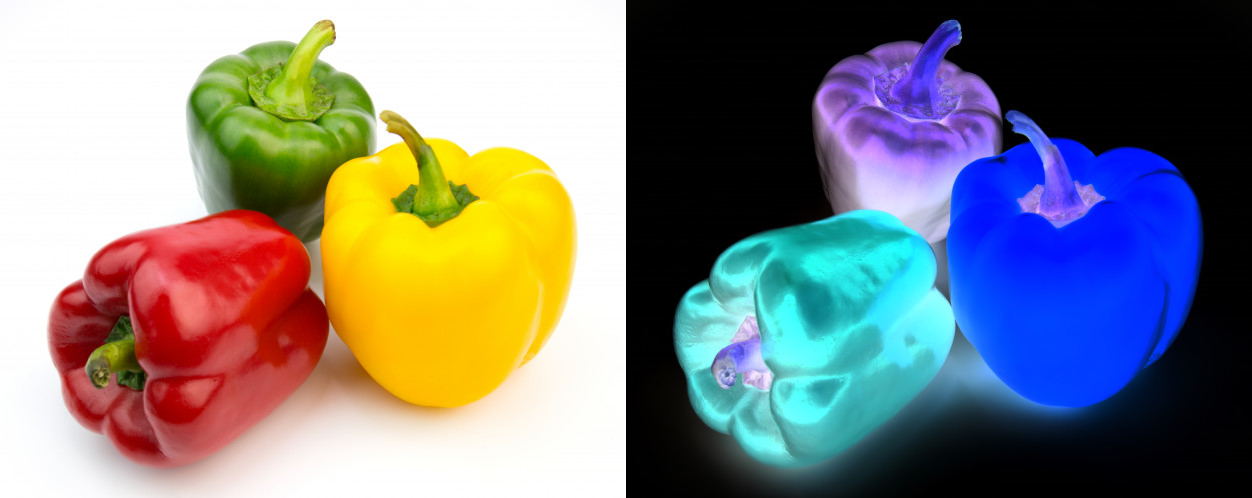

In [ ]:
img = cv.imread('/content/drive/MyDrive/PCVK/paprika.jpg')

inverted_img = 255 - img

final_frame = cv.hconcat([img, inverted_img])

cv2_imshow(final_frame)

### 2. Contrast Transformation

Mengubah tingkat kecerahan dan kontras citra
----------------------------------
Masukkan tingkat kecerahan: 10
Masukkan kontras: 1.5


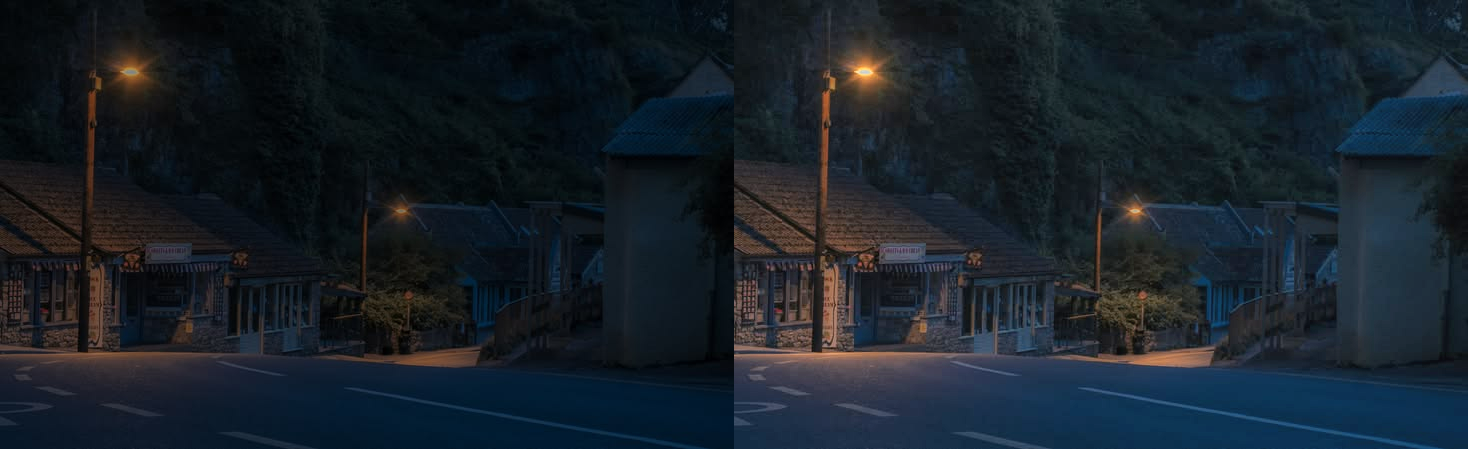

In [ ]:
print('Mengubah tingkat kecerahan dan kontras citra')
print('----------------------------------')

try:
    brightness = int(input('Masukkan tingkat kecerahan: '))
except ValueError:
    print('Error, bukan angka. Menggunakan nilai default 0')
    brightness = 0

try:
    contrast = float(input('Masukkan kontras: '))
except ValueError:
    print('Error, bukan angka. Menggunakan nilai default 1.0')
    contrast = 1.0

img = cv.imread('/content/drive/MyDrive/PCVK/night town.jpg')

adjusted_img = cv.convertScaleAbs(img, alpha=contrast, beta=brightness)

final_frame = cv.hconcat([img, adjusted_img])

cv2_imshow(final_frame)

### 3. Logarithmic Transformation

Mengubah tingkat kecerahan citra dengan Transformasi Log
------------------------------------------------------
Masukkan nilai kecerahan: 100


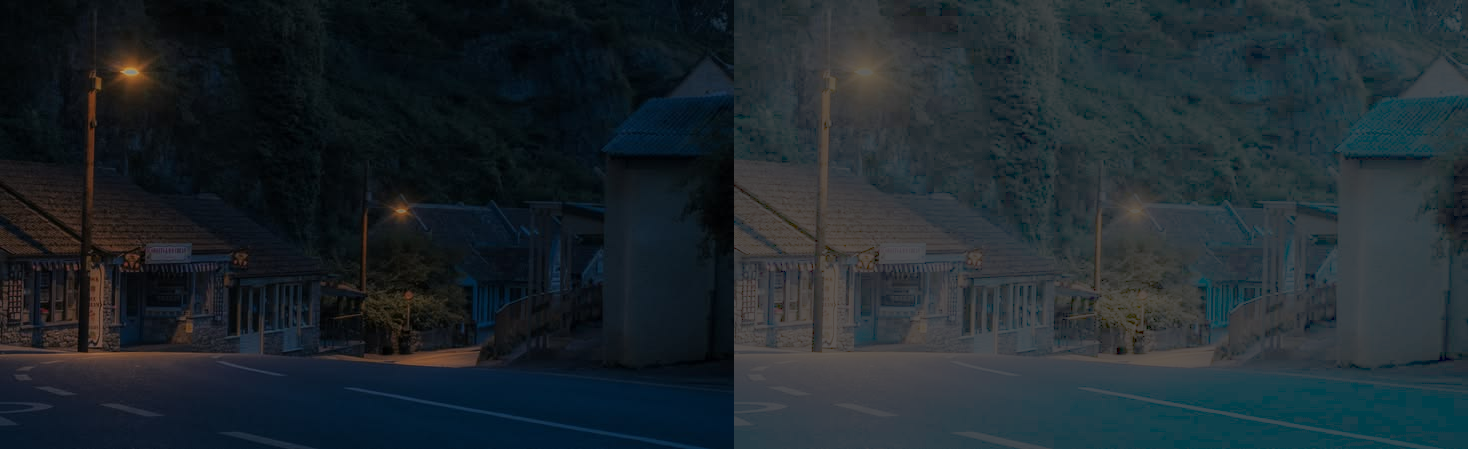

In [ ]:
print('Mengubah tingkat kecerahan citra dengan Transformasi Log')
print('------------------------------------------------------')

try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, bukan angka. Menggunakan nilai default 50')
    brightness = 50

img = cv.imread('/content/drive/MyDrive/PCVK/night town.jpg')

img_float = original.astype(np.float32)

# c = brightness / log(1 + r_max)
# s = c * log(1 + r)
c = brightness / np.log(1 + np.max(img_float))
log_image = c * np.log(1 + img_float)

log_image = np.clip(log_image, 0, 255).astype(np.uint8)

final_frame = cv.hconcat([img, log_image])

cv2_imshow(final_frame)

### 4. Grayscale Transformation (Averaging, lightness, luminance)

Transformasi Grayscale (Averaging, Lightness, Luminance)
---------------------------------------------------------


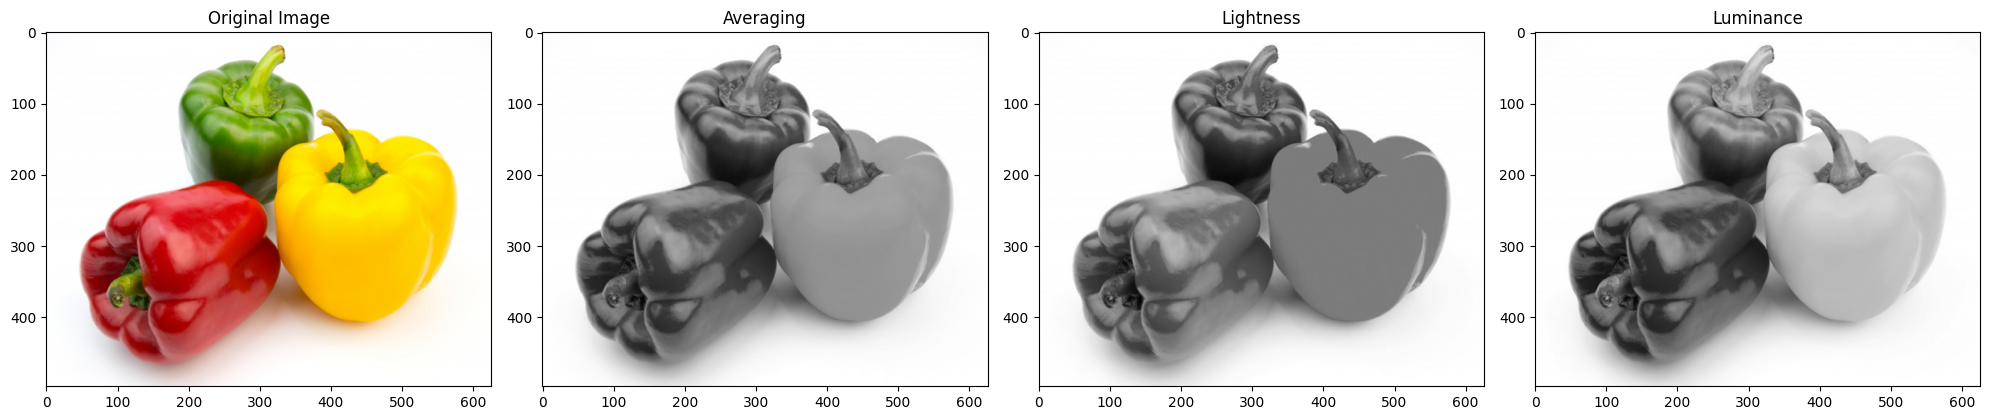

In [ ]:
import matplotlib.pyplot as plt

print('Transformasi Grayscale (Averaging, Lightness, Luminance)')
print('---------------------------------------------------------')

original = cv.imread('/content/drive/MyDrive/PCVK/paprika.jpg')

original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

b, g, r = cv.split(original)
r_f = r.astype(np.float32)
g_f = g.astype(np.float32)
b_f = b.astype(np.float32)

# a. Averaging
gray_averaging = ((r_f + g_f + b_f) / 3).astype(np.uint8)

# b. Lightness
max_rgb = np.maximum(np.maximum(r_f, g_f), b_f)
min_rgb = np.minimum(np.minimum(r_f, g_f), b_f)
gray_lightness = ((max_rgb + min_rgb) / 2).astype(np.uint8)

# c. Luminance
gray_luminance = (0.299 * r_f + 0.587 * g_f + 0.114 * b_f).astype(np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(original_rgb)
axes[0].set_title('Original Image')

axes[1].imshow(gray_averaging, cmap='gray')
axes[1].set_title('Averaging')

axes[2].imshow(gray_lightness, cmap='gray')
axes[2].set_title('Lightness')

axes[3].imshow(gray_luminance, cmap='gray')
axes[3].set_title('Luminance')

plt.tight_layout()
plt.show()

### 5. Display certain color on an image

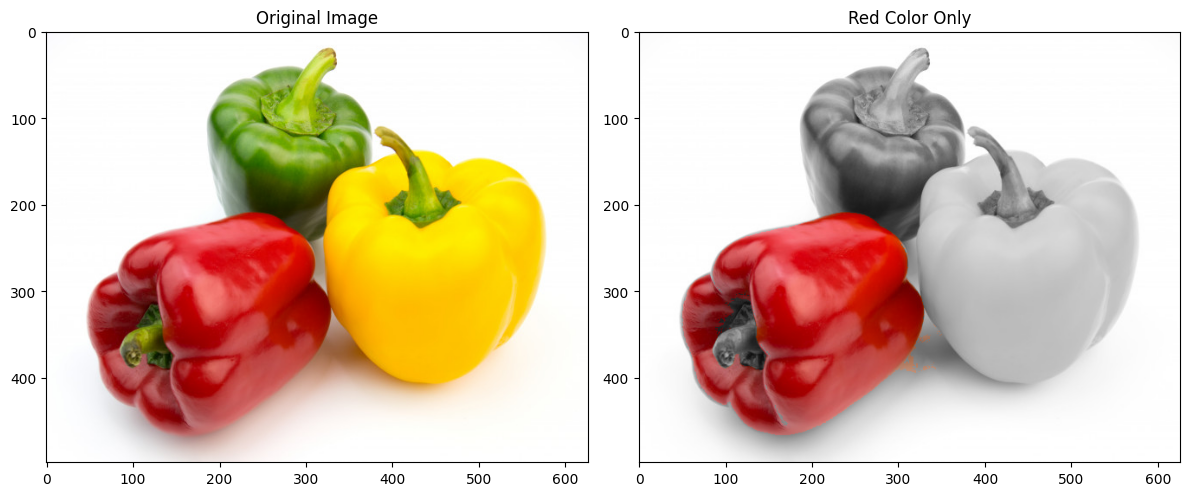

In [ ]:
original = cv.imread('/content/drive/MyDrive/PCVK/paprika.jpg')

hsv = cv.cvtColor(original, cv.COLOR_BGR2HSV)

# Red hue ranges in HSV
lower_red1 = np.array([0, 100, 100])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([170, 100, 100])
upper_red2 = np.array([180, 255, 255])

mask1 = cv.inRange(hsv, lower_red1, upper_red1)
mask2 = cv.inRange(hsv, lower_red2, upper_red2)
mask_red = cv.bitwise_or(mask1, mask2)

gray = cv.cvtColor(original, cv.COLOR_BGR2GRAY)
gray_bgr = cv.cvtColor(gray, cv.COLOR_GRAY2BGR)

# Extract red
red_extracted = cv.bitwise_and(original, original, mask=mask_red)
mask_inv = cv.bitwise_not(mask_red)
background_gray = cv.bitwise_and(gray_bgr, gray_bgr, mask=mask_inv)

# Combine
final_image = cv.add(red_extracted, background_gray)

original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)
final_rgb = cv.cvtColor(final_image, cv.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(original_rgb)
axes[0].set_title('Original Image')

axes[1].imshow(final_rgb)
axes[1].set_title('Red Color Only')

plt.tight_layout()
plt.show()

### 6. Gamma Correction

Masukkan nilai Gamma: 2


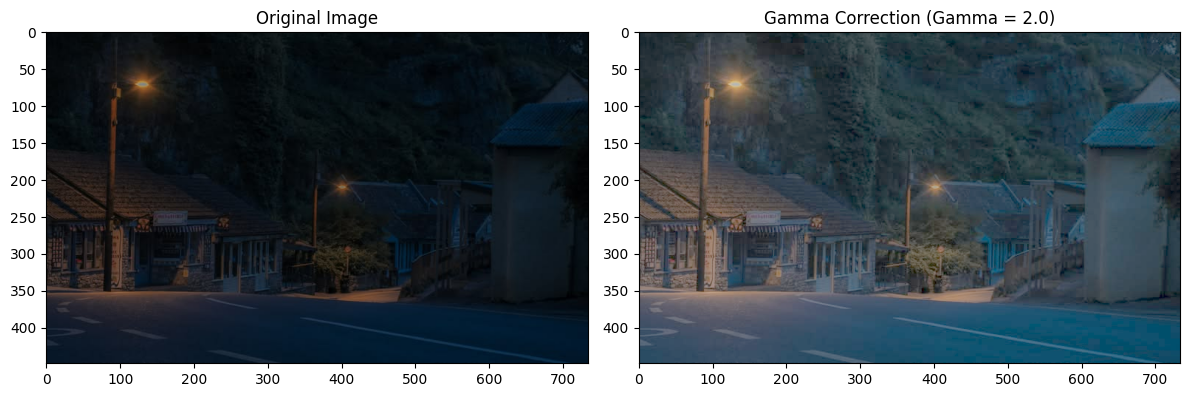

In [ ]:
try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, bukan angka. Menggunakan nilai default 1.0')
    gamma = 1.0

original = cv.imread('/content/drive/MyDrive/PCVK/night town.jpg')

# Gamma Correction: O = 255 * (I / 255) ^ (1 / gamma)
invGamma = 1.0 / gamma
table = np.array([((i / 255.0) ** invGamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
gamma_image = cv.LUT(original, table)

original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)
gamma_rgb = cv.cvtColor(gamma_image, cv.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(original_rgb)
axes[0].set_title('Original Image')

axes[1].imshow(gamma_rgb)
axes[1].set_title(f'Gamma Correction (Gamma = {gamma})')

plt.tight_layout()
plt.show()

### 7. Simulate image depth

Masukkan bit depth tujuan (1-8): 3
Bit depth awal  : 8 bit
Bit depth tujuan: 3 bit
Jumlah level    : 8


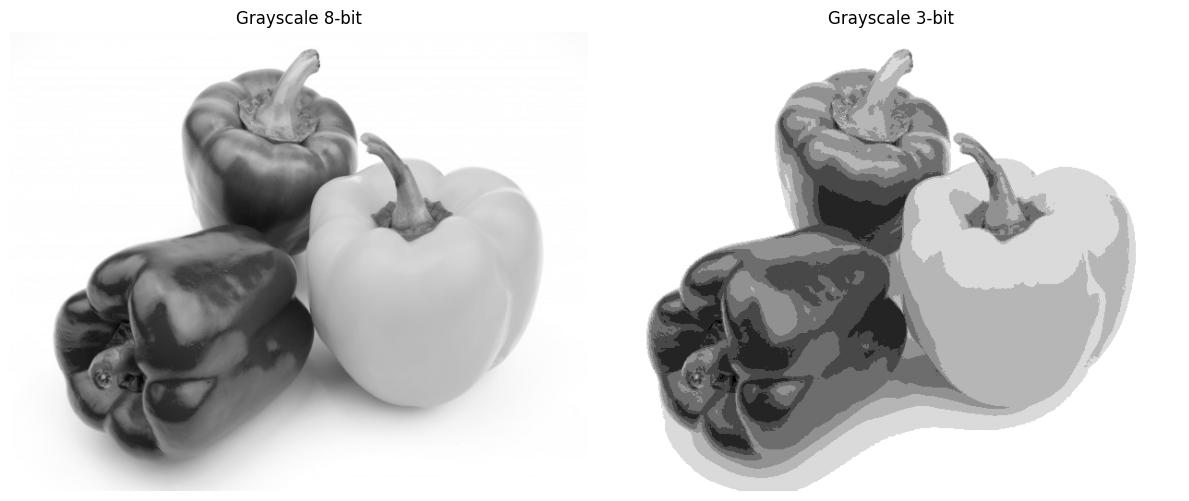

In [ ]:
try:
    bit_depth = int(input('Masukkan bit depth tujuan (1-8): '))
except ValueError:
    print('Error, bukan angka. Menggunakan nilai default 3')
    bit_depth = 3

if bit_depth < 1 or bit_depth > 8:
    print('Bit depth harus antara 1-8. Menggunakan nilai default 3')
    bit_depth = 3

num_levels = 2 ** bit_depth
level = 255 / (num_levels - 1)

original = cv.imread('/content/drive/MyDrive/PCVK/paprika.jpg', cv.IMREAD_GRAYSCALE)

depth_image = np.round(original / level) * level
depth_image = depth_image.astype(np.uint8)

print(f"Bit depth awal  : 8 bit")
print(f"Bit depth tujuan: {bit_depth} bit")
print(f"Jumlah level    : {num_levels}")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(original, cmap='gray')
axes[0].set_title('Grayscale 8-bit')
axes[0].axis('off')

axes[1].imshow(depth_image, cmap='gray')
axes[1].set_title(f'Grayscale {bit_depth}-bit')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### 8. Average Denoising Module

Total citra noise yang berhasil dimuat: 100 citra

--- Uji Coba 10 Citra ---
Jumlah Citra di-Average : 10
Nilai PSNR (dB)        : 19.7270
---------------------------------------------


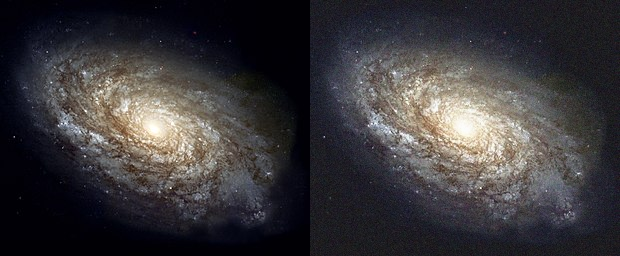


--- Uji Coba 20 Citra ---
Jumlah Citra di-Average : 20
Nilai PSNR (dB)        : 19.8340
---------------------------------------------


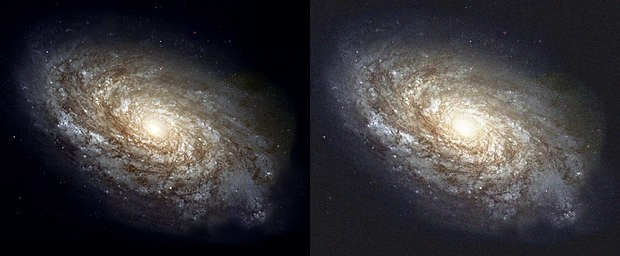


--- Uji Coba 40 Citra ---
Jumlah Citra di-Average : 40
Nilai PSNR (dB)        : 19.8902
---------------------------------------------


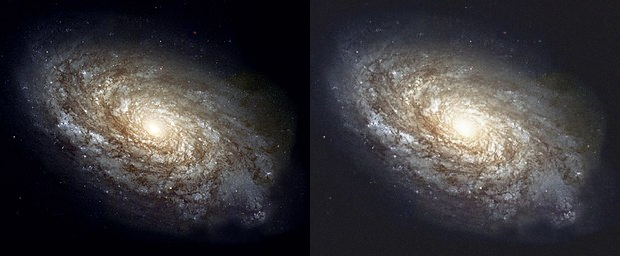


--- Uji Coba 80 Citra ---
Jumlah Citra di-Average : 80
Nilai PSNR (dB)        : 19.9174
---------------------------------------------


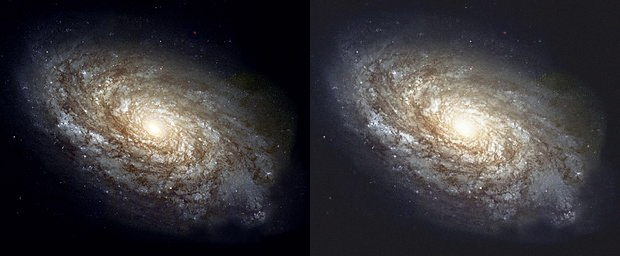


--- Uji Coba 100 Citra ---
Jumlah Citra di-Average : 100
Nilai PSNR (dB)        : 19.9220
---------------------------------------------


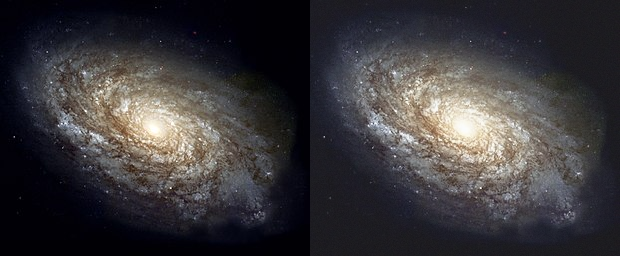

array([[[31, 25, 25],
        [33, 27, 27],
        [34, 26, 27],
        ...,
        [30, 26, 28],
        [32, 27, 30],
        [31, 26, 29]],

       [[34, 27, 28],
        [34, 27, 28],
        [33, 25, 26],
        ...,
        [31, 27, 29],
        [30, 26, 28],
        [31, 27, 29]],

       [[34, 27, 27],
        [31, 24, 24],
        [37, 29, 30],
        ...,
        [31, 28, 29],
        [33, 30, 31],
        [34, 32, 32]],

       ...,

       [[32, 27, 29],
        [32, 27, 29],
        [33, 28, 30],
        ...,
        [30, 26, 28],
        [29, 25, 27],
        [30, 26, 28]],

       [[32, 28, 29],
        [33, 28, 30],
        [33, 28, 29],
        ...,
        [33, 27, 29],
        [36, 29, 32],
        [32, 26, 28]],

       [[31, 27, 28],
        [34, 30, 31],
        [31, 26, 28],
        ...,
        [30, 24, 26],
        [33, 25, 28],
        [35, 27, 30]]], dtype=uint8)
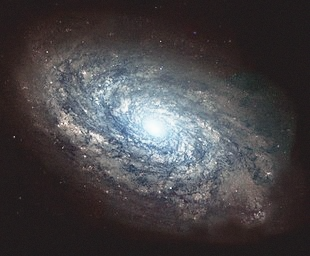

In [ ]:
import glob

original_path = '/content/drive/MyDrive/PCVK/galaxy.jpg'
original = cv.imread(original_path)

cv_img = []
for img in glob.glob('/content/drive/MyDrive/PCVK/noises/*.jpg'):
    n = cv.imread(img)
    if n is not None:
        cv_img.append(n)

print(f"Total citra noise yang berhasil dimuat: {len(cv_img)} citra\n")

#Fungsi untuk melakukan Average Denoising & Hitung PSNR
def run_average_denoising(num_images):
    from google.colab.patches import cv2_imshow

    if len(cv_img) < num_images:
        print(f"Peringatan: Jumlah citra tersedia ({len(cv_img)}) kurang dari {num_images}!")
        return

    subset = cv_img[:num_images]
    accumulated = np.zeros_like(subset[0], dtype=np.float32)

    for img in subset:
        accumulated += img.astype(np.float32)

    averaged_img = (accumulated / num_images).astype(np.uint8)
    psnr_value = cv.PSNR(original, averaged_img)

    print(f"Jumlah Citra di-Average : {num_images}")
    print(f"Nilai PSNR (dB)        : {psnr_value:.4f}")
    print("-" * 45)

    final_frame = cv.hconcat([original, averaged_img])
    cv2_imshow(final_frame)
    return averaged_img

# --- UJI COBA SESUAI TABEL ---
print("--- Uji Coba 10 Citra ---")
run_average_denoising(10)

print("\n--- Uji Coba 20 Citra ---")
run_average_denoising(20)

print("\n--- Uji Coba 40 Citra ---")
run_average_denoising(40)

print("\n--- Uji Coba 80 Citra ---")
run_average_denoising(80)

print("\n--- Uji Coba 100 Citra ---")
run_average_denoising(100)

Yes. Based on the result, the average increses, the PSNR value also increases. This tell that averaging more noisy frames reduces random Gaussian noise. The quality of the reconstructed image improves

### 9. Image Masking

Original Image:


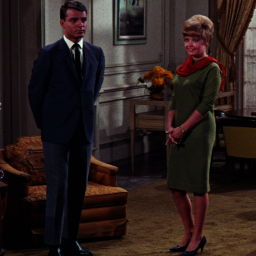

1. Binary Mask:


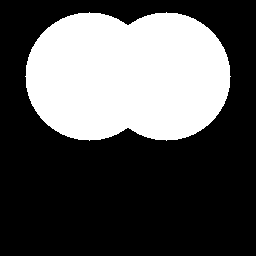

2. Operator AND (Standard Masking):


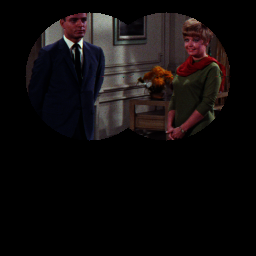

3. Operator NOT (Inverted Colors in Mask):


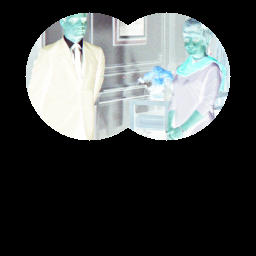

4. Operator OR (Mask Region Overwritten to White):


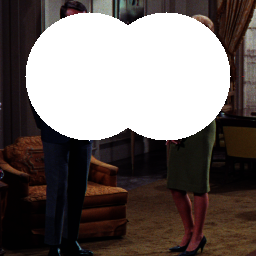

5. Operator XOR (Inverted Inside, Normal Outside):


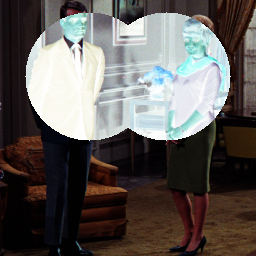

6. Operator NAND (NOT-AND within Mask):


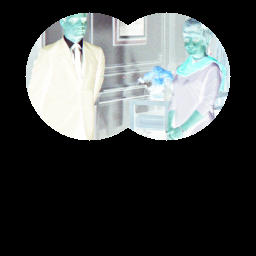

In [5]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

img_path = '/content/drive/MyDrive/PCVK/couple.tiff'
original = cv.imread(img_path)

# Ensure image is 8-bit 3-channel BGR
if original.dtype != np.uint8:
    original = cv.normalize(original, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

if len(original.shape) == 2:
    original = cv.cvtColor(original, cv.COLOR_GRAY2BGR)
elif original.shape[2] == 4:
    original = cv.cvtColor(original, cv.COLOR_BGRA2BGR)

h, w = original.shape[:2]

mask = np.zeros((h, w), dtype=np.uint8)
cv.circle(mask, (int(w * 0.35), int(h * 0.3)), int(h * 0.25), 255, -1)
cv.circle(mask, (int(w * 0.65), int(h * 0.3)), int(h * 0.25), 255, -1)

mask_bgr = cv.cvtColor(mask, cv.COLOR_GRAY2BGR)
not_mask = cv.bitwise_not(mask)

# 1. AND
res_and = cv.bitwise_and(original, original, mask=mask)

# 2. NOT
res_not = cv.bitwise_not(original, mask=mask)

# 3. OR
res_or = cv.bitwise_or(original, mask_bgr)

# 4. XOR
res_xor = cv.bitwise_xor(original, mask_bgr)

# 5. NAND
res_nand = cv.bitwise_not(res_and, mask=mask)

# --- DISPLAY ---
print("Original Image:")
cv2_imshow(original)

print("1. Binary Mask:")
cv2_imshow(mask)

print("2. Operator AND (Standard Masking):")
cv2_imshow(res_and)

print("3. Operator NOT (Inverted Colors in Mask):")
cv2_imshow(res_not)

print("4. Operator OR (Mask Region Overwritten to White):")
cv2_imshow(res_or)

print("5. Operator XOR (Inverted Inside, Normal Outside):")
cv2_imshow(res_xor)

print("6. Operator NAND (NOT-AND within Mask):")
cv2_imshow(res_nand)

### 10. Night time picture

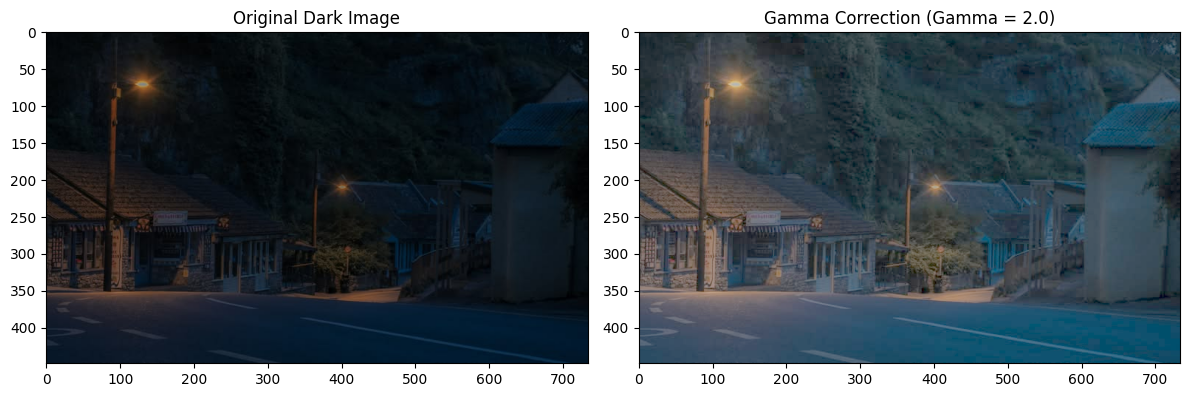

In [6]:
import matplotlib.pyplot as plt

img_path = '/content/drive/MyDrive/PCVK/night town.jpg'
original = cv.imread(img_path)

original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

gamma = 2.0
inv_gamma = 1.0 / gamma

table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
gamma_image = cv.LUT(original_rgb, table)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(original_rgb)
axes[0].set_title('Original Dark Image')

axes[1].imshow(gamma_image)
axes[1].set_title(f'Gamma Correction (Gamma = {gamma})')

plt.tight_layout()
plt.show()

I chose gamma correction. Because it selectively lifts dark mid tones and shadow details while compressing highlights, expanding shadow visibility without clipping bright lights to pure white. But the risk are noise amplification, loss of contrast, and color distortion

### 11. Repair Crawfish Image

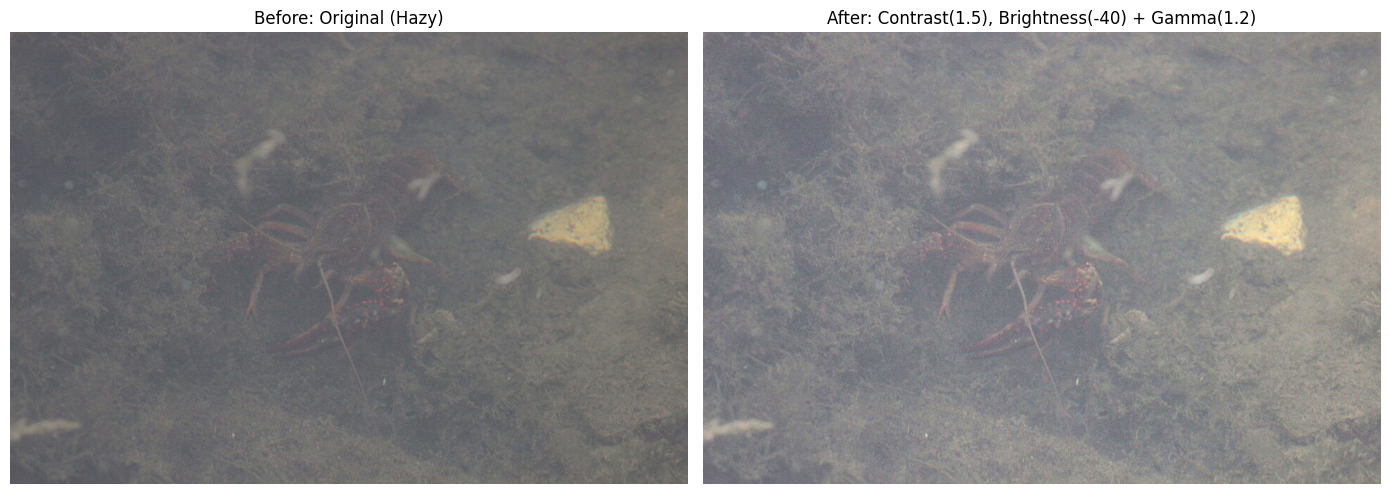

In [10]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img_path = '/content/drive/MyDrive/PCVK/crayfish.jpg'
original = cv.imread(img_path)

original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

# Linear Contrast and Brightness Adjustment
# alpha = 1.5 (Contrast multiplier to stretch pixel values)
# beta = -40 (Brightness subtraction to remove the gray fog)
alpha = 1.5
beta = -40
contrast_img = cv.convertScaleAbs(original_rgb, alpha=alpha, beta=beta)

# Gamma Correction
# gamma = 1.2 (Lifts the mid-tones slightly so the crayfish isn't too dark)
gamma = 1.2
inv_gamma = 1.0 / gamma
table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
final_result = cv.LUT(contrast_img, table)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(original_rgb)
axes[0].set_title('Before: Original (Hazy)')
axes[0].axis('off')

axes[1].imshow(final_result)
axes[1].set_title(f'After: Contrast({alpha}), Brightness({beta}) + Gamma({gamma})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In my opinition to repair the quality of the hazy, low-contrast underwater image of the crayfish using basic operations, the most effective approach is a combination of Linear Contrast/Brightness adjustment, followed by Gamma Correction. Because the image suffers from a severe "fog" effect, the pixel values are clumped together in a narrow range of dull grays. Adding brightness would only make this fog worse. By applying a strong Linear Contrast (multiplication), we stretch the pixel intensities to separate the crayfish from the background, while reducing the Linear Brightness (subtraction) cuts out the overall gray haze of the water. Finally, applying a slight Gamma Correction (power-law) helps retrieve the darker details of the crayfish that might have become too dark during the contrast adjustment, ensuring the colors and textures remain visible